In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# se utiliza para el manejo de rutas y directorios.
import os

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

Ejemplos por clase antes del balanceo:
14    57825
18    48419
20    29008
2     23409
19    22495
Name: count, dtype: int64

Se tomarán 1120 ejemplos por clase para balancear.

Dataset balanceado con 29120 ejemplos en total.
Ejemplos de entrenamiento: 23296
Ejemplos de prueba: 5824
Entrenando clase 0...
Entrenando clase 1...
Entrenando clase 2...
Entrenando clase 3...
Entrenando clase 4...
Entrenando clase 5...
Entrenando clase 6...
Entrenando clase 7...
Entrenando clase 8...
Entrenando clase 9...
Entrenando clase 10...
Entrenando clase 11...
Entrenando clase 12...
Entrenando clase 13...
Entrenando clase 14...
Entrenando clase 15...
Entrenando clase 16...
Entrenando clase 17...
Entrenando clase 18...
Entrenando clase 19...
Entrenando clase 20...
Entrenando clase 21...
Entrenando clase 22...
Entrenando clase 23...
Entrenando clase 24...
Entrenando clase 25...

Precisión del modelo en el conjunto de prueba: 69.66%


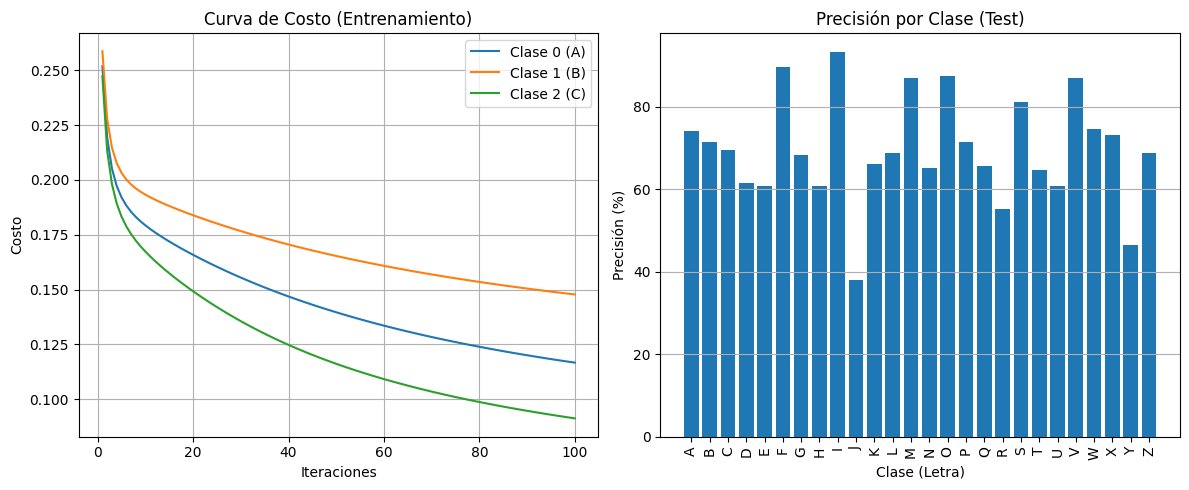

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

df = pd.read_csv('/content/drive/MyDrive/SIS420/datasets/A_Z Handwritten Data.csv', header=None)

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

X = X / 255.0

# 3. BALANCEO DEL DATASET

print("Ejemplos por clase antes del balanceo:")
print(pd.Series(y).value_counts().head())

min_samples = pd.Series(y).value_counts().min()
print(f"\nSe tomarán {min_samples} ejemplos por clase para balancear.")


df_balanced = pd.DataFrame(X)
df_balanced['label'] = y


dfs = []
for label in range(26):
    class_data = df_balanced[df_balanced['label'] == label]
    dfs.append(class_data.sample(n=min_samples, random_state=42))

df_balanced = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)

X = df_balanced.drop(columns=['label']).values
y = df_balanced['label'].values

print(f"\nDataset balanceado con {len(X)} ejemplos en total.")

# 4. DIVISIÓN 80% ENTRENAMIENTO / 20% PRUEBA

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ejemplos de entrenamiento: {X_train.shape[0]}")
print(f"Ejemplos de prueba: {X_test.shape[0]}")


# 5. MODELO ONE-VS-ALL
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(theta, X, y, lambda_):
    m = len(y)
    h = sigmoid(X @ theta)

    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    J = (1/m) * (-y.T @ np.log(h) - (1-y).T @ np.log(1-h)) + (lambda_ / (2*m)) * np.sum(theta[1:]**2)
    return J


def gradient_descent(X, y, theta, alpha, iterations, lambda_):
    m = len(y)
    J_history = []

    for i in range(iterations):
        h = sigmoid(X @ theta)
        gradient = (1/m) * (X.T @ (h - y))

        gradient[1:] = gradient[1:] + (lambda_ / m) * theta[1:]

        theta = theta - (alpha * gradient)
        J_history.append(cost_function(theta, X, y, lambda_))

    return theta, J_history

# Función para entrenar "One vs All"
def one_vs_all(X, y, num_labels, alpha, iterations, lambda_):
    m, n = X.shape
    # Agregamos la columna de unos
    X = np.hstack((np.ones((m, 1)), X))

    all_theta = np.zeros((num_labels, n + 1))
    cost_histories = []

    for i in range(num_labels):
        print(f"Entrenando clase {i}...")

        y_binary = (y == i).astype(int)

        initial_theta = np.zeros(n + 1)
        theta, J_hist = gradient_descent(X, y_binary, initial_theta, alpha, iterations, lambda_)

        all_theta[i] = theta
        cost_histories.append(J_hist)

    return all_theta, cost_histories, X

# Parámetros del modelo
num_labels = 26
alpha = 0.1
iterations = 100
lambda_ = 0.1

# Entrenamiento
all_theta, cost_histories, X_train_bias = one_vs_all(X_train, y_train, num_labels, alpha, iterations, lambda_)

# 6. PREDICCIÓN Y EVALUACIÓN

def predict_one_vs_all(X, all_theta):

    X = np.hstack((np.ones((X.shape[0], 1)), X))
    probs = sigmoid(X @ all_theta.T)
    return np.argmax(probs, axis=1)

y_pred = predict_one_vs_all(X_test, all_theta)

# Precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrecisión del modelo en el conjunto de prueba: {accuracy * 100:.2f}%")

# 7. GRÁFICAS DE COSTO Y PRECISIÓN

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(3):
    plt.plot(range(1, iterations + 1), cost_histories[i], label=f'Clase {i} ({chr(65+i)})')
plt.xlabel('Iteraciones')
plt.ylabel('Costo')
plt.title('Curva de Costo (Entrenamiento)')
plt.legend()
plt.grid(True)

# Gráfica de barras de precisión por clase
plt.subplot(1, 2, 2)
class_accuracies = []
for i in range(num_labels):
    idx = (y_test == i)
    if np.sum(idx) > 0:
        acc = np.mean(y_pred[idx] == y_test[idx])
        class_accuracies.append(acc * 100)
    else:
        class_accuracies.append(0)

plt.bar(range(26), class_accuracies)
plt.xlabel('Clase (Letra)')
plt.ylabel('Precisión (%)')
plt.title('Precisión por Clase (Test)')
plt.xticks(range(26), [chr(65+i) for i in range(26)], rotation=90)
plt.grid(axis='y')

plt.tight_layout()
plt.show()